# Probability III
# Gaussian Processes

This article is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20I%20-%20Discrete%20Distributions.ipynb">Probability I - Discrete Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20II%20-%20Continuous%20Distributions.ipynb">Probability II - Continuous Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20III%20-%20Gaussian%20Processes.ipynb">Probability III - Gaussian Processes</a>

# Outline

- History and Applications
- Theoretical Justification
- The Multivariate Gaussian
- Marginalization
- Conditioning
- Kernels
- Application: GP Regression
- Prediction
- Posterior
- Combining Kernels
- Multiple Dimensions
- Application: Classification
- Application: Surrogate Optimization Function
- Advantages and Disadvantages
- sklearn Implementation Details
- References

### History and Applications

Gaussian processes (GPs) originate from the field of probability theory, and offer a robust and flexible framework for modeling complex data.

-----
<i>"Gaussian process prediction is also well known in the geostatistics field where it is known as kriging, and in meteorology, although this literature has focused mostly on two and three-dimensional input spaces."</i>
- Gaussian Processes for Machine Learning (2006)
-----

Kriging, i.e. GP regression, is used in mining, hydrology, environmental science, agriculture, and meteorology, and is a method of interpolation that provides the best linear unbiased predictor (BLUP) of a variable at unobserved locations based on observed data and spatial correlation structure.

In optimization and simulation studies, GP regression can be used to create surrogate models that approximate expensive-to-evaluate functions. This is a key component in Bayesian optimization techniques, used for hyperparameter tuning in machine learning models.

We can also adapt Gaussian processes to solve classification or clustering problems.

-----
<i>"Gone are the days where simple equations are regarded as sufficient to describe real-world systems. Physicists figured that out 50 years ago; industrial engineers followed suit. Biologists, social scientists, climate scientists and weather forecasters have jumped on the bandwagon rather more recently.</i>
- Surrogates (2020)
-----

### Theoretical Justification

Some analytical reasons to use GPs are as follows:
- They are non-parametric, and can therefore approximate any continuous function given enough data.
- They are interpreted probablistically and provide the estimated uncertainty of predictions.
- The marginal likelihood can be optimized using hyperparameters.
- Convergence and consistency: the posterior mean converges to the true function as the number of observations increases.

A random field is a collection of random variables indexed by spatial or temporal coordinates, and in spatial contexts, describes how a variable varies across a region. One can think of a GP as defining a distribution over these functions, and inference taking place in the space of functions. A GP defines a prior over functions, and is a collection of random variables, any finite number of which have a joint Gaussian distribution. As in probablistic linear regression, we assume samples can be modelled by some function plus Gaussian noise. If we take the function itself to be a GP, we can use all the properties of Multivariate Gaussians, a.k.a. Multivariate Normals or MVNs (I will use MVN for shorthand, as that is what's commonly used).


### The Multivariate Gaussian

GPs involve working with the MVN, which a random vector $\mathbf{X} = (X_1, \ldots, X_k)$ has if every linear combination of the $X_j$ has a Gaussian distribution. A MVN is fully specified if the mean vector $\mathbf{\mu}$ and covariance matrix $\mathbf{\Sigma}$ are known.

$
\mathcal{N}(\mathbf{y} | \mathbf{\mu}, \mathbf{\Sigma}) = 
\frac{1}{ (2 \pi)^{D/2} |\mathbf{\Sigma}|^{1/2} }
exp \left[ -\frac{1}{2} (\mathbf{y} - \mathbf{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{y} - \mathbf{\mu}) \right]     
$
- $D$ is the number of dimensions

#### Visualizing the Bivariate Gaussian

A bivariate Gaussian in 3D space looks as follows:

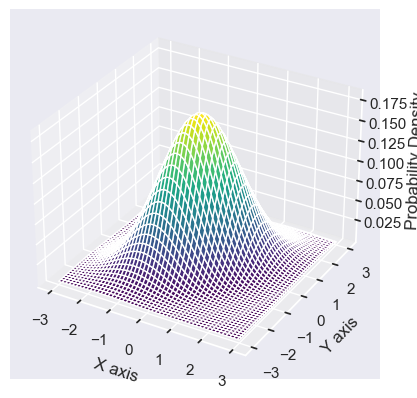

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# Parameters for the bivariate normal distribution
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]  # Diagonal covariance

# Create grid and multivariate normal
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal(mean, cov)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Z = rv.pdf(pos)
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Probability Density')
plt.show()

<i>Whereas the univariate Gaussian looks like a cross-section of a bell in 2D space, a bivariate Gaussian looks like a complete bell in 3D space.</i>

#### MVN Attributes

MVNs have the following attractive properties:
- The density function sums to $1$.
- Any linear combination of components is Gaussian.
- The marginal densities of any subset of elements are also Gaussian.
- The conditional densities of any subset of elements are also Gaussian.
- The sum of independent Gaussian random variables is also Gaussian.

As the MVN is a multi-dimensional generalization of the Gaussian, the GP is an infinite-dimensional generalization of the MVN. Using finite data does not remove the underlying infinite-dimensional structure, but does mean you only need to work with a finite set of observations.

Gaussians have the nice property of being closed under conditioning and marginalization, making problems in machine learning tractable. An advantage of working with a MVN is that we can use the covariance matrix to encode information, via the kernel function. A kernel function determines how much influence one data point has on predicting the value of another.

### Marginalization 

GPs define a probability distribution over possible functions in such as way that, at each point you evaluate a function, it places a Gaussian distribution with given mean and variance. This distribution is commonly centered to revolve around $\mathbf{\mu} = \mathbf{0}$.

Through marginalization, we can extract partial information from multivariate distributions. Given a Gaussian probability distribution $P(X,Y)$ over vectors of random variables $X$ and $Y$:

- $X \sim \mathcal{N}(\mathbf{\mu}_X, \mathbf{\Sigma}_{XX})$
- $Y \sim \mathcal{N}(\mathbf{u}_Y, \mathbf{\Sigma}_{YY})$

Each partition $X$ and $Y$ only depends on its corresponding entries in $\mathbf{\mu}$ and $\mathbf{\Sigma}$. To marginalize out a random variable from a Gaussian distribution, we can simply drop the variables from $\mathbf{\mu}$ and $\mathbf{\Sigma}$.

$p_X(x) = \int_y p_{X,Y}(x,y) ~dy = \int_y p_{X,Y}(x|y) ~p_Y(y) ~dy$

The interpretation is that if we are interested in the probability density of $X=x$, we need to consider all possible outcomes of $Y$ that can jointly lead to the result.

### Conditioning

Conditioning is used to determine the probability of one variable depending on another variable. Similar to marginalization, this operation is closed and yields a modified Gaussian distribution. This operation allows Bayesian inference.

- $X|Y \sim \mathcal{N} (\mathbf{\mu}_X + \mathbf{\Sigma}_{XY} \mathbf{\Sigma}_{YY}^{-1} (Y - \mathbf{\mu}_Y), \mathbf{\Sigma}_{XX} - \mathbf{\Sigma_{XY} \mathbf{\Sigma}_{YY}^{-1} \mathbf{\Sigma}_{YX}})$

- $Y|X \sim \mathcal{N} (\mathbf{\mu}_Y + \mathbf{\Sigma}_{YX} \mathbf{\Sigma}_{XX}^{-1} (X - \mathbf{\mu}_X), \mathbf{\Sigma}_{YY} - \mathbf{\Sigma}_{YX} \mathbf{\Sigma}_{XX}^{-1} \mathbf{\Sigma}_{XY})$

We form the joint distribution $P_{X,Y}$ between the test points $X$ and the training points $Y$, resulting in a multivariate Gaussian with dimensions $|Y|+|X|$. We concatenate the training and test points to compute the corresponding covariance matrix. Under conditioning, we can find $P_{X|Y}$ from $P_{X,Y}$. The dimensions of this new distribution matches the number of test points $N$ and the distribution is normal.

### Kernels

Assume we can model a variable $Y$ as a function $f$ of $X$ plus some Gaussian noise.

- $Y \sim \mathcal{N}(\mu=f(X), \sigma=\varepsilon)$

If $f$ is a linear function of $X$, then this assumption is essentially the same as simple linear regression. If we use a more general expression for $f$ by setting a prior over it, we will be able to get more complex functions than linear. If we decided to use Gaussian processes as the prior, we can write:

- $f(X) = \mathcal{GP}(\mu_X, \mathcal{K}(\mathbf{X}, \mathbf{X'}))$

A variety of kernel functions are available, such as the following:

<img src="img/kernels.png" style="height: 350px; width:auto;">

- <i>Play around with this at https://distill.pub/2019/visual-exploration-gaussian-processes/</i>


For the periodic kernel, we have parameter $p$, which determines periodicity, and with the linear kernel, we have parameter $c$, which allows us to change the point on which all functions hinge. A kernel could be implemented as a mixture (a multiplication or addition) of multiple kernel functions.

A more extensive discussion of kernels can be found at <a href="www.cs.toronto.edu/~durenaud/cookbook">www.cs.toronto.edu/~durenaud/cookbook</a>.

### Application: GP Regression

Below, we'll implement Gaussian process regression. I'll start by creating some training data to work with.

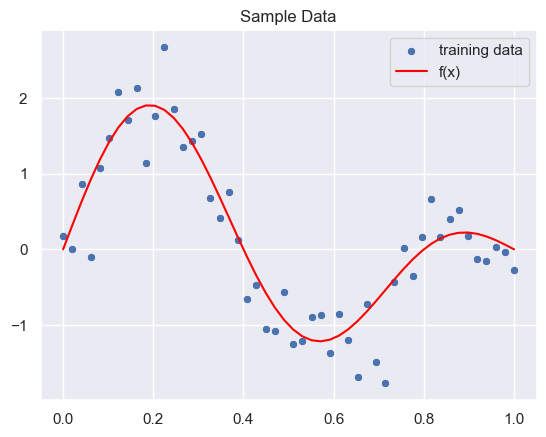

In [2]:
n = 50
x = np.linspace(start=0, stop=1, num=n)

def f(x):
    f = np.sin((3*np.pi)*x) + np.sin((2*np.pi)*x)
    return(f)

f_x = f(x)

sigma_n = 0.4
epsilon = np.random.normal(loc=0, scale=sigma_n, size=n)
y = f_x + epsilon

fig, ax = plt.subplots()
sns.scatterplot(x=x, y=y, label='training data', ax=ax);
sns.lineplot(x=x, y=f_x, color='red', label='f(x)', ax=ax);
ax.set(title='Sample Data')
ax.legend(loc='upper right');

Then, define a kernel function. There are many options, but we'll simply go with the radial basis function (RBF), which bears similarity to the univariate Gaussian, and is parameterized by $\sigma_f$ and $\ell$.

- $\text{cov}(f(x_p), f(x_q)) = k_{\sigma_f, \ell}(x_p, x_q) = \sigma_f \exp\left(-\frac{1}{2\ell^2} ||x_p - x_q||^2\right)$

In [3]:
def kernel_function(x, y, sigma_f=1, l=1):
    kernel = sigma_f * np.exp(- (np.linalg.norm(x - y)**2) / (2 * l**2))
    return kernel

### Prediction

We form the joint distribution $P_{X_*,X}$ between the test points $X_*$ and the training points $X$, resulting in a multivariate Gaussian with dimensions $|X|+|X_*|$. We concatenate the training and test points to compute the corresponding covariance matrix. Under conditioning, we can find $P_{X_*|X}$ from $P_{X_*,X}$.

The joint distribution of $y$ and $f_*$ is given by:

$
\begin{bmatrix}
y \\ 
f_* \\
\end{bmatrix}
\sim \mathcal{N}(0, C)
$

where

- $C = \begin{bmatrix} K(X, X) + \sigma^2_n I & K(X, X_*) \\ K(X_*, X) & K(X_*, X_*) \\ \end{bmatrix}$

- $\sigma_n^2 I$ is a term to account for noise.

First, we select parameters and compute the covariance matrices.

In [4]:
# Adapted from https://juanitorduz.github.io/gaussian_process_reg/

import itertools

n_star = 50
x_star = np.linspace(start=0, stop=1, num=n_star)

# parameters
l = 0.1
sigma_f = 2

def compute_cov_matrices(x, x_star, sigma_f=1, l=1):
    """
    K = K(X, X) 
    K_star = K(X_*, X)
    K_star2 = K(X_*, X_*)
    """
    n = x.shape[0]
    n_star = x_star.shape[0]
    K = [kernel_function(i, j, sigma_f=sigma_f, l=l) for (i, j) in itertools.product(x, x)]
    K = np.array(K).reshape(n, n)
    K_star2 = [kernel_function(i, j, sigma_f=sigma_f, l=l) for (i, j) in itertools.product(x_star, x_star)]
    K_star2 = np.array(K_star2).reshape(n_star, n_star)
    K_star = [kernel_function(i, j, sigma_f=sigma_f, l=l) for (i, j) in itertools.product(x_star, x)]
    K_star = np.array(K_star).reshape(n_star, n)    
    return (K, K_star2, K_star)

K, K_star2, K_star = compute_cov_matrices(x, x_star, sigma_f=sigma_f, l=l)

Then, concatenate the covariance matrices together.

(100, 50)
(100, 50)
(100, 100)


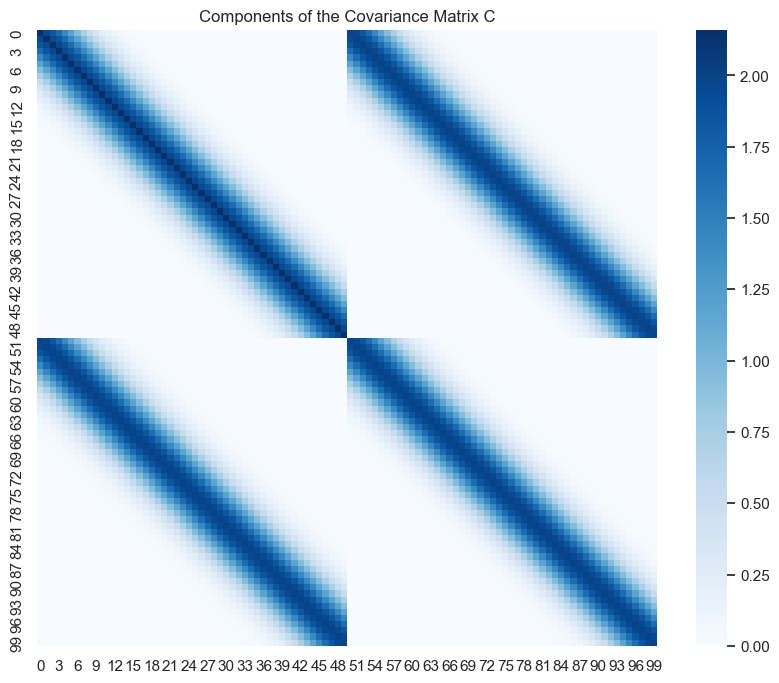

In [5]:
a = np.concatenate((K + (sigma_n**2)*np.eye(n), K_star), axis=0)
print(a.shape)

b = np.concatenate((K_star.T, K_star2), axis=0)
print(b.shape)

C = np.concatenate((a, b), axis=1)
print(C.shape)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data=C, cmap='Blues', ax=ax)
ax.set(title='Components of the Covariance Matrix C');

We can draw samples from the prior if we'd like, to see what kind of functions we are likely to observe.

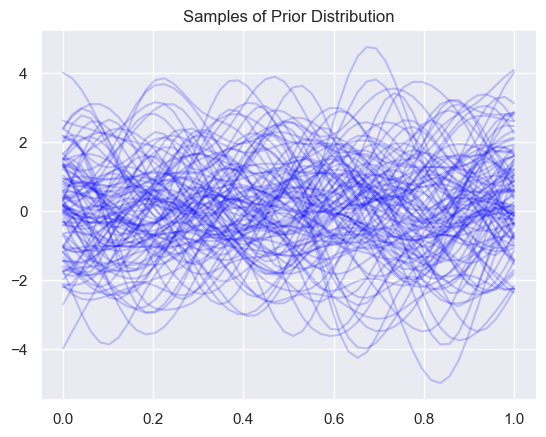

In [6]:
fig, ax = plt.subplots()

for i in range(0, 100):
    z_star = np.random.multivariate_normal(mean=np.zeros(n_star), cov=K_star2)
    sns.lineplot(x=x_star, y=z_star, color='blue', alpha=0.2, ax=ax)
    
ax.set(title='Samples of Prior Distribution');

### Posterior

To get the posterior distribution over functions, we need to restrict this joint prior distribution to contain only those functions which agree with the observed data points. We are interested in computing $f_*|X, y, X_*$. These can be found as:

$f_*|X, y, X_* \sim \mathcal{N}(\bar{f}_*, \text{cov}(f_*))$

where

- $\bar{f}_* = K(X_*, X)(K(X, X) + \sigma^2_n I)^{-1} y$

- $\text{cov}(f_*) = K(X_*, X_*) - K(X_*, X)(K(X, X) + \sigma^2_n I)^{-1} K(X, X_*)$

Below, we compute these parameters and then visualize the covariance matrix resulting from the calculation.

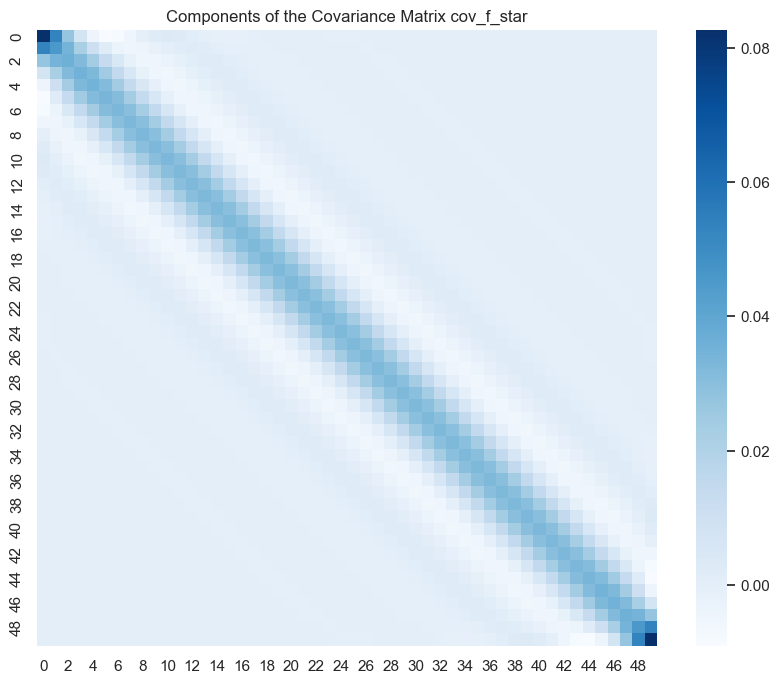

In [7]:
def compute_gpr_parameters(K, K_star2, K_star, sigma_n):
    n = K.shape[0]
    f_bar_star = np.dot(K_star, np.dot(np.linalg.inv(K + (sigma_n**2)*np.eye(n)), y.reshape([n, d])))
    cov_f_star = K_star2 - np.dot(K_star, np.dot(np.linalg.inv(K + (sigma_n**2)*np.eye(n)), K_star.T))
    
    return (f_bar_star, cov_f_star)

# dimensions
d = 1
f_bar_star, cov_f_star = compute_gpr_parameters(K, K_star2, K_star, sigma_n)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data=cov_f_star, cmap='Blues', ax=ax)
ax.set_title('Components of the Covariance Matrix cov_f_star');

Below, we draw samples from the posterior.

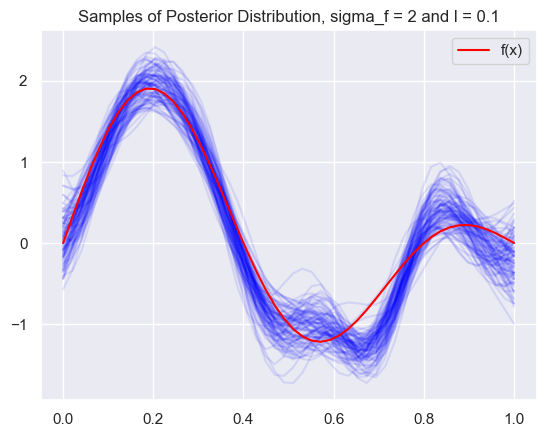

In [8]:
fig, ax = plt.subplots()

for i in range(0, 100):
    # Sample from posterior distribution. 
    z_star = np.random.multivariate_normal(mean=f_bar_star.squeeze(), cov=cov_f_star)

    sns.lineplot(x=x_star, y=z_star, color="blue", alpha=0.1, ax=ax);
    
# Plot "true" linear fit.
sns.lineplot(x=x, y=f_x, color='red', label = 'f(x)', ax=ax)
ax.set(title=f'Samples of Posterior Distribution, sigma_f = {sigma_f} and l = {l}')
ax.legend(loc='upper right');

#### sk-learn Implementation

Below, we'll use the scikit-learn implementation, and extend the x-axis in order to predict the future.

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

In [10]:
# Set dimension. 
d = 1

# Length of the training set. 
L = 1

# Generate training features.
x = np.linspace(start=0, stop=L, num=n)
X = x.reshape(n, d)

# Generate noise
sigma_n = 0.4
epsilon = np.random.normal(loc=0, scale=sigma_n, size=n)

f_x = f(x)
y = f_x + epsilon

In [11]:
n_star = n + 50
x_star = np.linspace(start=0, stop=(L + 0.25), num=n_star)

X_star = x_star.reshape(n_star, d)

# Define kernel parameters. 
l = 0.01
sigma_f = 1

# Define kernel object. 
kernel = ConstantKernel(constant_value=sigma_f, constant_value_bounds=(1e-2, 1e2)) \
            * RBF(length_scale=l, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(kernel=kernel, alpha=sigma_n**2, n_restarts_optimizer=10, )
gp.fit(X, y)
y_pred = gp.predict(X_star)

In [12]:
# Generate samples from posterior distribution. 
y_hat_samples = gp.sample_y(X_star, n_samples=n_star)

# Compute the mean of the sample. 
y_hat = np.apply_over_axes(func=np.mean, a=y_hat_samples, axes=1).squeeze()

# Compute the standard deviation of the sample. 
y_hat_sd = np.apply_over_axes(func=np.std, a=y_hat_samples, axes=1).squeeze()

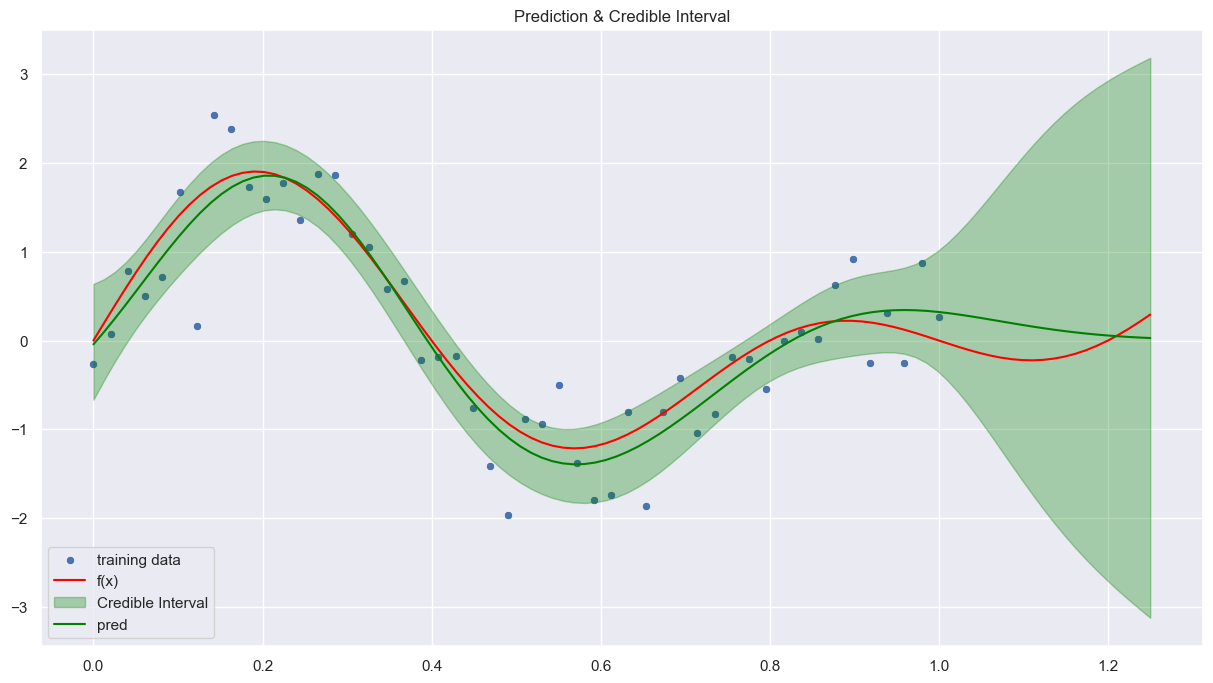

In [13]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.scatterplot(x=x, y=y, label='training data', ax=ax);

sns.lineplot(
    x=x_star, 
    y=f(x_star), 
    color='red', 
    label='f(x)', 
    ax=ax
)

ax.fill_between(
    x=x_star, 
    y1=(y_hat - 3*y_hat_sd), 
    y2=(y_hat + 3*y_hat_sd), 
    color='green',
    alpha=0.3, 
    label='Credible Interval'
)

sns.lineplot(x=x_star, y=y_pred, color='green', label='pred')
ax.set(title='Prediction & Credible Interval')
ax.legend(loc='lower left');

### Combining Kernels

In the following <code>sklearn</code> implementation from their user guide, multiple kernels are combined into order to account for the linear, seasonal, and noise components of a time-series trend of atmospheric CO2 concentrations.

In [14]:
# Import Libraries

from sklearn.datasets import fetch_openml
import polars as pl
import datetime

import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ExpSineSquared
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.gaussian_process.kernels import WhiteKernel

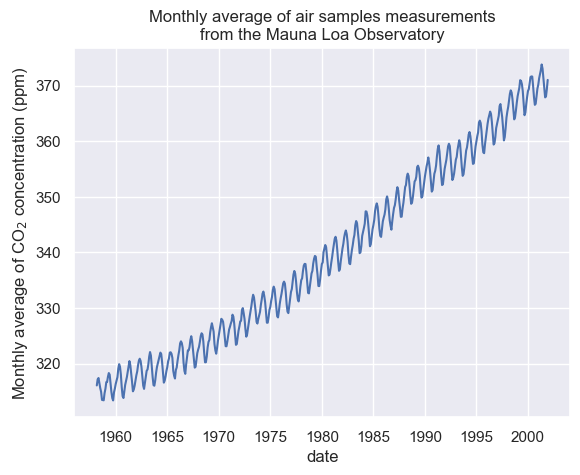

In [15]:
# Import Data

co2 = fetch_openml(data_id=41187, as_frame=True)

co2_data = pl.DataFrame(co2.frame[["year", "month", "day", "co2"]]).select(
    pl.date("year", "month", "day"), "co2"
)

co2_data = (
    co2_data.sort(by="date")
    .group_by_dynamic("date", every="1mo")
    .agg(pl.col("co2").mean())
    .drop_nulls()
)
plt.plot(co2_data["date"], co2_data["co2"])
plt.xlabel("date")
plt.ylabel("Monthly average of CO$_2$ concentration (ppm)")
plt.title("Monthly average of air samples measurements\nfrom the Mauna Loa Observatory");

In [16]:
# Combine Kernels

long_term_trend_kernel = 50.0**2 * RBF(length_scale=50.0)

seasonal_kernel = (
    2.0**2
    * RBF(length_scale=100.0)
    * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
)

irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=1.0, alpha=1.0)

noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(
    noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5)
)

co2_kernel = (
    long_term_trend_kernel + seasonal_kernel + irregularities_kernel + noise_kernel
)

co2_kernel

50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=1) + 0.5**2 * RationalQuadratic(alpha=1, length_scale=1) + 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01)

In [17]:
# Fit Model to Data

X = co2_data.select(
    pl.col("date").dt.year() + pl.col("date").dt.month() / 12
).to_numpy()
y = co2_data["co2"].to_numpy()

y_mean = y.mean()
gp = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False)
gp = gp.fit(X, y - y_mean)

Notice that the kernel of the regressor has adjusted the kernel parameters during fit.

In [18]:
gp.kernel_

44.8**2 * RBF(length_scale=51.6) + 2.64**2 * RBF(length_scale=91.5) * ExpSineSquared(length_scale=1.48, periodicity=1) + 0.536**2 * RationalQuadratic(alpha=2.89, length_scale=0.968) + 0.188**2 * RBF(length_scale=0.122) + WhiteKernel(noise_level=0.0367)

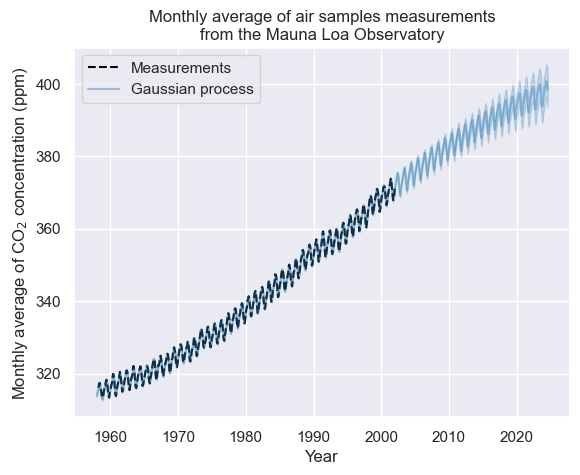

In [19]:
# Plot Predictions

today = datetime.datetime.now()
current_month = today.year + today.month / 12
X_test = np.linspace(start=1958, stop=current_month, num=1_000).reshape(-1, 1)
mean_y_pred, std_y_pred = gp.predict(X_test, return_std=True)
mean_y_pred += y_mean

plt.plot(X, y, color="black", linestyle="dashed", label="Measurements")
plt.plot(X_test, mean_y_pred, color="tab:blue", alpha=0.4, label="Gaussian process")
plt.fill_between(
    X_test.ravel(),
    mean_y_pred - std_y_pred,
    mean_y_pred + std_y_pred,
    color="tab:blue",
    alpha=0.2,
)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Monthly average of CO$_2$ concentration (ppm)")
_ = plt.title(
    "Monthly average of air samples measurements\nfrom the Mauna Loa Observatory"
)

### Multiple Dimensions

Multiple dimensions can be accomodated by the nature of the distance metric used in the covariance matrix. To keep it simple, let's just consider Euclidean distance. The following matrix is a vector with elements $[1, 2, 3]$, and so, as an example, the second row of the first column of the distance matrix is equal to $\sqrt{(2-1)^2} = 1$, and the third row of the first column is equal to $\sqrt{(3-1)^2} = 2$.

In [6]:
from scipy.spatial import distance_matrix
x = np.array([[1],[2],[3]])
distance_matrix(x,x,p=2)

array([[0., 1., 2.],
       [1., 0., 1.],
       [2., 1., 0.]])

Now, I'll create a matrix with 3 rows and 3 columns.

In [4]:
X = np.array([[1,2,3],[4,5,6],[7,8,9]])
X

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [10]:
distance_matrix(X,X)

array([[ 0.        ,  5.19615242, 10.39230485],
       [ 5.19615242,  0.        ,  5.19615242],
       [10.39230485,  5.19615242,  0.        ]])

The distance matrix is the same size. The second row of the first column of the distance matrix is equal to:

$\sqrt{ (4-1)^2 + (5-2)^2 + (6-3)^2 } = \sqrt{9+9+9} = 5.9615...$

The third row of the first column is equal to:

$\sqrt{ (7-1)^2 + (8-2)^2 + (9-3)^2 } = \sqrt{36+36+36} = 10.3923....$

etc.

### Application: Classification

Classification using GPs involves restricting the output to a range of $0$ to $1$, such that the predictions reflect probabilities. With GP regression, the prior, likelihood, and posterior were all Gaussian, but for classification, we will put the output through a function like the logistic, softmax, or Gaussian CDF (called probit regression).

Supposing our data has class labels $-1$ and $+1$, our task is to predict $\pi(\mathbf{x})$, the probability that an example with input vector $\mathbf{x}$ is of class $+1$. 

Inference is divided into two steps:

1. Compute the distribution of the latent variable corresponding to a test case, 

    $p(f_*|\mathbf{X},\mathbf{y},\mathbf{x}_*) = \int p(f_*|\mathbf{X}, \mathbf{x}_*, \mathbf{f}) ~p(\mathbf{f}|X,y) ~d \mathbf{f}$

    where where $p(\mathbf{f}|\mathbf{X},\mathbf{y}) = p(\mathbf{y}|\mathbf{f}) ~p(f_*|\mathbf{X} / p(\mathbf{y}|X)$ is the posterior over the latent variables, and

2. Use this distribution of the latent $f_*$ to produce a probablistic prediction.

    $p(y_* = +1|\mathbf{X}, \mathbf{y}, \mathbf{x}_* = \int \sigma(f_*) p(f_*|\mathbf{X}, \mathbf{y}, \mathbf{x}_*) ~d f_*$

With the probabilities predicted, class labels can then be predicted based on a threshold.


#### sklearn Implementation

Scikit-Learn has <code>GaussianProcessClassifier</code>, and although slow compared to many algorithms, it produces highly reasonable looking predictions upon the Iris dataset. 

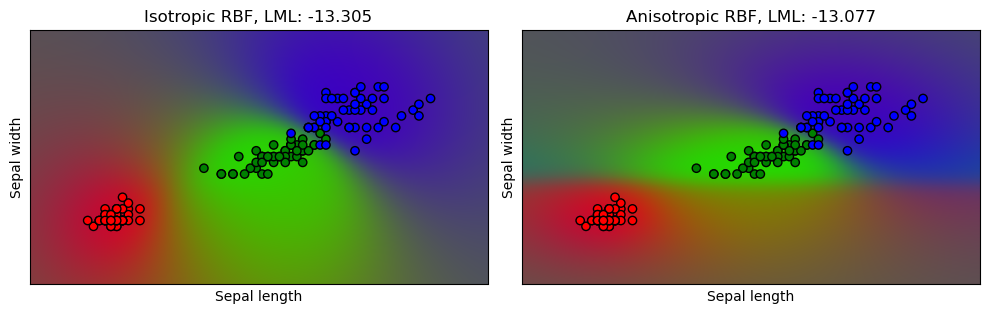

In [1]:
# code is adapted from the sklearn User Guide

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, 2:4]  # we only take the first two features.
y = np.array(iris.target, dtype=int)

h = 0.02  # step size in the mesh

kernel = 1.0 * RBF([1.0])
gpc_rbf_isotropic = GaussianProcessClassifier(kernel=kernel).fit(X, y)
kernel = 1.0 * RBF([1.0, 1.0])
gpc_rbf_anisotropic = GaussianProcessClassifier(kernel=kernel).fit(X, y)

# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles = ["Isotropic RBF", "Anisotropic RBF"]
plt.figure(figsize=(10, 5))
for i, clf in enumerate((gpc_rbf_isotropic, gpc_rbf_anisotropic)):
    # Plot the predicted probabilities. For that, we will assign a color to
    # each point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(1, 2, i + 1)

    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape((xx.shape[0], xx.shape[1], 3))
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin="lower")

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=np.array(["r", "g", "b"])[y], edgecolors=(0, 0, 0))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(
        "%s, LML: %.3f" % (titles[i], clf.log_marginal_likelihood(clf.kernel_.theta))
    )

plt.tight_layout()
plt.show()

The smooth prediction areas are quite pleasant to look at. These two features were particularly informative toward predicting the class membership, so to further illustrate how the algorithm partitions uncertainty, I'll go with less distinctive features:

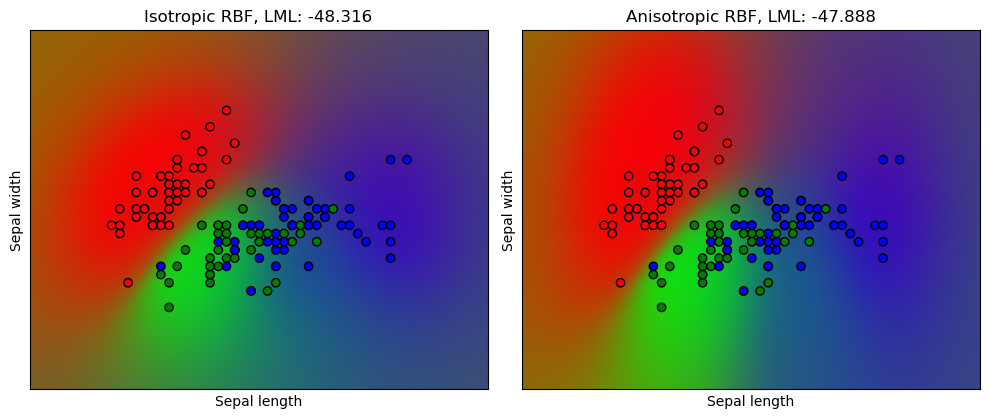

In [2]:
iris = datasets.load_iris()
X = iris.data[:, 0:2]  # we only take the first two features.
y = np.array(iris.target, dtype=int)

h = 0.02  # step size in the mesh

kernel = 1.0 * RBF([1.0])
gpc_rbf_isotropic = GaussianProcessClassifier(kernel=kernel).fit(X, y)
kernel = 1.0 * RBF([1.0, 1.0])
gpc_rbf_anisotropic = GaussianProcessClassifier(kernel=kernel).fit(X, y)

# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles = ["Isotropic RBF", "Anisotropic RBF"]
plt.figure(figsize=(10, 5))
for i, clf in enumerate((gpc_rbf_isotropic, gpc_rbf_anisotropic)):
    # Plot the predicted probabilities. For that, we will assign a color to
    # each point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(1, 2, i + 1)

    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape((xx.shape[0], xx.shape[1], 3))
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin="lower")

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=np.array(["r", "g", "b"])[y], edgecolors=(0, 0, 0))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(
        "%s, LML: %.3f" % (titles[i], clf.log_marginal_likelihood(clf.kernel_.theta))
    )

plt.tight_layout()
plt.show()

### Application: Surrogate Optimization Function

In Bayesian optimization, a method for optimizing black-box functions that are expensive to evaluate, a GP can be used as a surrogate model to approximate the objective function. GPs provide measures of uncertainty, which can inform decisions pertaining to the explore/exploit dilemma.

-----
<i>"The terminology ['surrogate'] came out of physics, applied math and engineering literatures, where the use of mathematical models leveraging numerical solvers has been commonplace for some time. As such models became more complex, requiring more resources to simulate/solve numerically, practitioners increasingly relied on meta-models built off of limited simulation campaigns... The canonical surrogate model, a fitted Gaussian process (GP) regression, which was borrowed for computer experiments from the geostatistics' kriging literature of the 1960s, enjoys wide applicability."</i>
- Surrogates (2020)
-----

The process looks as follows:

1. Initialization: start with a few initial evaluations of the objective function.

2. Fit the GP: use the initial data to fit a GP model, providing predictions of the objective function and their uncertainties.

3. Acquisition Function: define an acquisition function that balances exploration and exploitation. Common acquisition functions include expected improvement (EI), upper confidence bound (UCB), and probability of improvement.

4. Optimize the Acquisition Function: use numerical optimization methods to maximize the acquisition function. The point that maximizes it is the point where the objective function should be evaluated next.

5. Update the GP: evaluate the objective function at the suggested point, update the dataset with this new point, and refit the GP model.

6. Re-iterate until convergence criteria are met.

### Advantages and Disadvantages of GPs

<h4>Advantages</h4>

- GPs are non-parametric, so they do not assume a fixed form for the underlying function theya re trying to model, allowing them to adapt to the complexity of the data.

- GPs provide a natural way to quantify uncertainty; they give a distribution over possible functions.

- Flexible in terms of covariance function and hyperparameters.

- Incorporation of prior knowledge, via choice of mean, covariance function, and parameters.

<h4>Disadvantages</h4>

- GPs scale poorly with the size of the dataset.

- Performance depends of choice of kernel function and hyperparameters.

- Interpreting the influence of individual data points and understanding the overall model behavior can be less straightforward compared to parametric models.

### References

- Rasumussen, C., & Williams, C. (2006). Gaussian Processes for Machine Learning (2nd ed.). MIT Press. https://gaussianprocess.org/gpml/chapters/RW.pdf

- Gramacy, R. B. (2020). Surrogates: Gaussian process modeling, design and optimization for the applied sciences. CRC Press. https://bookdown.org/rbg/surrogates/

- Gortler, J., Kehlbeck, R., & Deussen, O. (2019, April 2). A Visual Exploration of Gaussian Processes. Distill. https://distill.pub/2019/visual-exploration-gaussian-processes/

- (2019, September 21). An Introduction to Gaussian Process Regression. Juanitorduz.Github.io. https://juanitorduz.github.io/gaussian_process_reg/

- Murphy, K. P. (2022). Probablistic Machine Learning (2nd ed.). MIT Press. https://probml.github.io/pml-book/book1.html

- Roberts, S., Osborne, M., Ebden, M., Reece, S., Gibson, N., & Aigrain, S. (2012). Gaussian Processes for Timeseries Modelling. University of Oxford. https://www.robots.ox.ac.uk/~sjrob/Pubs/philTransA_2012.pdf

- [Youtube]. Freitas, N. D. (2013, February 4). Machine learning - Introduction to Gaussian processes [Video]. UBC. https://www.youtube.com/watch?v=4vGiHC35j9s&list=PLE6Wd9FR--EdyJ5lbFl8UuGjecvVw66F6&index=9

- [Youtube]. Freitas, N. D. (2013, February 5). Machine learning - Gaussian processes [Video]. UBC. https://www.youtube.com/watch?v=MfHKW5z-OOA&list=PLE6Wd9FR--EdyJ5lbFl8UuGjecvVw66F6&index=10

- (n.d.). Interactive Gaussian Process Visualization. Infinitely Curious. http://www.infinitecuriosity.org/vizgp/